In [2]:
from matplotlib import pyplot as plt
import ffmpeg
import numpy as np

from PIL import Image
from IPython.display import display
from ipywidgets import interact
import ipywidgets as widgets

## Read audio

In [13]:
input_path = r"..\inputs\3-29-01.mov"

out, _ = (ffmpeg
    .input(input_path)
    .output('pipe:1', format='s16le', acodec='pcm_s16le', ac=1, ar='16k')
    # .overwrite_output()
    .run(capture_stdout=True)
)

audio_np = np.frombuffer(out, np.float32)

# Optional: If you want to work with floating point values normalized between -1 and 1:
# audio_float = audio_np.astype(np.float32) / 32768.0

In [14]:
audio_np

array([0., 0., 0., ..., 0., 0., 0.], dtype=float32)

In [7]:
from utils.io import get_audio_binary, get_video, split_by_segments, pick_clips, merge_clips, speed_up_video

video = get_video(input_path)
audio_binary = get_audio_binary(video)


{'video_found': True, 'audio_found': True, 'metadata': {'compatible_brands': 'qt', 'major_brand': 'qt', 'minor_version': '512', 'creation_time': '2025-03-30T15:20:23.000000Z', 'modification_time': '2025-03-30T15:20:37.000000Z', 'Hw': '1', 'bitrate': '3400000', 'maxrate': '0', 'te_is_reencode': '1', 'mp4_data_incomplete': 'false', 'encoder': 'Lavf61.1.100'}, 'inputs': [{'streams': [{'input_number': 0, 'stream_number': 0, 'stream_type': 'video', 'language': None, 'default': True, 'size': [480, 854], 'bitrate': 2398, 'fps': 30.0, 'codec_name': 'hevc', 'profile': '(Main)', 'metadata': {'Metadata': '', 'creation_time': '2025-03-30T15:20:23.000000Z', 'handler_name': 'VideoHandler', 'vendor_id': 'FFMP'}}, {'input_number': 0, 'stream_number': 1, 'stream_type': 'audio', 'language': None, 'default': True, 'fps': 44100, 'bitrate': 192, 'metadata': {'Metadata': '', 'creation_time': '2025-03-30T15:20:23.000000Z', 'handler_name': 'SoundHandler', 'vendor_id': '[0][0][0][0]'}}], 'input_number': 0}], '

MoviePy - Done.


In [9]:
audio_binary

array([-3.7843119e-08,  2.9239800e-08, -1.9199824e-08, ...,
        5.5693126e-06, -4.0745881e-06,  2.7341664e-06], dtype=float32)

### Read video

In [ ]:
input_path = r".\3-29-01.mov"

probe = ffmpeg.probe(input_path)
video_info = next(s for s in probe['streams'] if s['codec_type'] == 'video')
width = int(video_info['width'])
height = int(video_info['height'])

width, height
total_frames = int(video_info.get('nb_frames', 0))
if total_frames == 0:
    total_frames = int(video_info['duration_ts'])
total_frames

In [ ]:
# Read all frames into memory with GPU decoding
out, _ = (
    ffmpeg
    .input(input_path, hwaccel='cuda')
    .output('pipe:', format='rawvideo', pix_fmt='rgb24')
    .run(capture_stdout=True, capture_stderr=True)
)

frames = np.frombuffer(out, np.uint8).reshape([-1, height, width, 3])

In [ ]:
assert frames.shape[0] == total_frames
frames.shape

(692, 894, 480, 3)

## Read frame

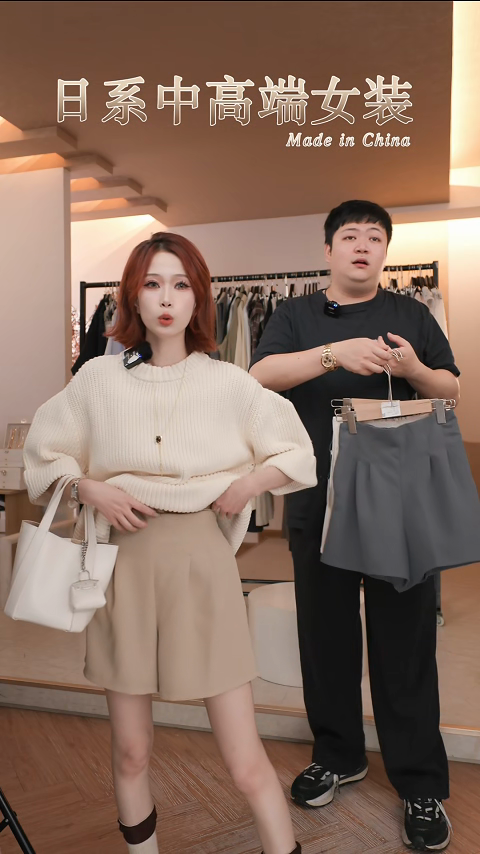

In [13]:
input_path = r"..\inputs\3-29-01.mov"
frame_num = 5840

out = (
    ffmpeg
    .input(input_path, hwaccel='cuda')
    .filter('select', f'eq(n,{frame_num})')
    .output('outputs/frame.png', vframes=1)  # Output 1 frame
    .overwrite_output()  # Allow overwriting if file exists
    .run()
)

# display the image
img = Image.open('./outputs/frame.png')
display(img)


In [14]:

call_qwenvl(model, processor, system_prompt, user_prompt, img)

'对'

## Init AI

In [2]:
from transformers import Qwen2_5_VLForConditionalGeneration, AutoProcessor
from qwen_vl_utils import process_vision_info

In [ ]:
model = Qwen2_5_VLForConditionalGeneration.from_pretrained(
    "Qwen/Qwen2.5-VL-32B-Instruct-AWQ", torch_dtype="auto", device_map="auto"
)
processor = AutoProcessor.from_pretrained(
    "Qwen/Qwen2.5-VL-32B-Instruct-AWQ",
    use_fast=False,
)

## Inference by AI model

In [7]:
def call_qwenvl(model, processor, system_prompt, user_prompt, image):
    messages = [
        {
            "role": "user",
            "content": [
                {
                    "type": "image",
                    "image": image,
                },
                {"type": "text", "text": user_prompt},
            ],
        }
    ]
    if system_prompt:
        messages.insert(0, {"role": "system", "content": system_prompt})

    # Preparation for inference
    text = processor.apply_chat_template(
        messages, tokenize=False, add_generation_prompt=True
    )
    image_inputs, video_inputs = process_vision_info(messages)
    inputs = processor(
        text=[text],
        images=image_inputs,
        videos=video_inputs,
        padding=True,
        return_tensors="pt",
    )
    inputs = inputs.to("cuda")

    # Inference: Generation of the output
    generated_ids = model.generate(**inputs, max_new_tokens=128)
    generated_ids_trimmed = [
        out_ids[len(in_ids) :] for in_ids, out_ids in zip(inputs.input_ids, generated_ids)
    ]
    output_text = processor.batch_decode(
        generated_ids_trimmed, skip_special_tokens=True, clean_up_tokenization_spaces=False
    )
    return output_text[0]

In [8]:
system_prompt = """你是一个专业的直播视频分析AI，任务是从视频中精准筛选出符合直播销售要求的片段。"""
user_prompt = (
    "请根据以下标准判断当前画面是否符合直播销售要求\n"
    "1. 主体为女性，正面清晰展示所售服装\n"
    "2. 表情自然放松，无遮挡或夸张面部动作，不能闭眼！\n"
    "3. 动作优雅得体，完整展示服装版型\n"
    "4. 服装在画面中占比≥40%，光照良好无阴影遮挡\n"
    "5.画面清晰，无模糊抖动\n"
    "符合所有条件时返回\"对\"，否则返回\"不\":\n"
)
# user_prompt = '手部模糊吗？'
        

In [ ]:
img = Image.open('outputs/frame.png')
display(img)
call_qwenvl(model, processor, system_prompt, user_prompt, img)

In [2]:
import asyncio

async def run_ffmpeg_async():
    # The command to run
    cmd = [
        "ffmpeg",
        "-i", r"..\inputs\3-29-01.mov",
        "-vf", r"select=eq(n\,200)",
        "-frames:v", "1",
        "-f", "image2pipe",  # output format to pipe the image
        "pipe:1"            # write to stdout
    ]
    
    # Create subprocess; stdout, stderr are captured asynchronously
    process = await asyncio.create_subprocess_exec(
        *cmd,
        stdout=asyncio.subprocess.PIPE,
        stderr=asyncio.subprocess.PIPE
    )
    
    # Wait for the process to finish, capturing output
    stdout, stderr = await process.communicate()
    
    # Handle success or error
    if process.returncode == 0:
        print("Frame extracted successfully.")
        if stdout:
            print("FFmpeg output:\n", stdout.decode())
    else:
        print("Error during FFmpeg execution. Return code:", process.returncode)
        if stderr:
            print("FFmpeg error output:\n", stderr.decode())
    return stdout

await run_ffmpeg_async()


NotImplementedError: 

## Extract audio

In [4]:
input_path = r"C:\videos\迪士尼\素材\18.m4v"
output_path = r"C:\videos\迪士尼\test2.wav"

(
    ffmpeg
    .input(input_path)
    .output(
        output_path, 
        vn=True,        # Disable video
        ar=16000,       # Audio sample rate (16kHz)
        ac=1,           # Mono audio
        acodec='pcm_s16le',  # 16-bit WAV
        f='wav'         # Output format
    )
    .overwrite_output()    # Allow overwriting if file exists
    .run()
)

(None, None)

In [5]:
input_file = input_path
probe = ffmpeg.probe(input_file)
video_info = next(s for s in probe['streams'] if s['codec_type'] == 'video')
width = int(video_info['width'])
height = int(video_info['height'])


duration = float(video_info.get('duration', 0))

# Get average frame rate (e.g., "30/1" → 30 fps)
avg_frame_rate = eval(video_info.get('avg_frame_rate', '0/0'))
fps = avg_frame_rate if avg_frame_rate else 0

num_frames = int(duration * fps)
num_frames

1073

In [8]:
# hours, mins, secs = video_info['tags']['DURATION'].split(':')
# secs, microsecs = secs.split('.')
# total_seconds = (
#     int(hours) * 3600 
#     + int(mins) * 60 
#     + int(secs) 
#     + int(microsecs) // 1_000_000
# )
video_info

{'index': 0,
 'codec_name': 'hevc',
 'codec_long_name': 'H.265 / HEVC (High Efficiency Video Coding)',
 'profile': 'Main',
 'codec_type': 'video',
 'codec_tag_string': 'hvc1',
 'codec_tag': '0x31637668',
 'width': 1080,
 'height': 1920,
 'coded_width': 1088,
 'coded_height': 1920,
 'closed_captions': 0,
 'film_grain': 0,
 'has_b_frames': 1,
 'sample_aspect_ratio': '1:1',
 'display_aspect_ratio': '9:16',
 'pix_fmt': 'yuv420p',
 'level': 120,
 'color_range': 'tv',
 'color_space': 'bt709',
 'color_transfer': 'bt709',
 'color_primaries': 'bt709',
 'chroma_location': 'left',
 'field_order': 'progressive',
 'refs': 1,
 'view_ids_available': '',
 'view_pos_available': '',
 'id': '0x1',
 'r_frame_rate': '30/1',
 'avg_frame_rate': '30/1',
 'time_base': '1/30',
 'start_pts': 0,
 'start_time': '0.000000',
 'duration_ts': 1073,
 'duration': '35.766667',
 'bit_rate': '7493444',
 'nb_frames': '1073',
 'extradata_size': 132,
 'disposition': {'default': 1,
  'dub': 0,
  'original': 0,
  'comment': 0,


In [9]:
num_frames = int(total_seconds * fps)
num_frames

177450

In [10]:
out, err = (
    ffmpeg
    .input(input_file, **{'hwaccel': 'cuda'})
    .output('pipe:', format='rawvideo', pix_fmt='rgb24')
    .run(capture_stdout=True)
)
video = (
    np
    .frombuffer(out, np.uint8)
    .reshape([-1, height, width, 3])
)

@interact(frame=(0, num_frames))
def show_frame(frame=0):
    plt.imshow(video[frame,:,:,:])

MemoryError: 

In [4]:
from io import BytesIO
from PIL import Image


def extract_frame(stream, frame_num):
    while isinstance(stream, ffmpeg.nodes.OutputStream):
        stream = stream.node.incoming_edges[0].upstream_node.stream()
    out, _ = (
        stream
        .filter_('select', 'gte(n,{})'.format(frame_num))
        .output('pipe:', format='rawvideo', pix_fmt='rgb24', vframes=1)
        .run(capture_stdout=True, capture_stderr=True)
    )
    return np.frombuffer(out, np.uint8).reshape([height, width, 3])


def png_to_np(png_bytes):
    buffer = BytesIO(png_bytes)
    pil_image = Image.open(buffer)
    return np.array(pil_image)
    

def build_graph(
        enable_overlay, flip_overlay, enable_box, box_x, box_y,
        thickness, color):

    stream = ffmpeg.input('in.mp4')

    if enable_overlay:
        overlay = ffmpeg.input('overlay.png')
        if flip_overlay:
            overlay = overlay.hflip()
        stream = stream.overlay(overlay)

    if enable_box:
        stream = stream.drawbox(
            box_x, box_y, 120, 120, color=color, t=thickness)

    return stream.output('out.mp4')


def show_image(ax, stream, frame_num):
    try:
        image = extract_frame(stream, frame_num)
        ax.imshow(image)
        ax.axis('off')
    except ffmpeg.Error as e:
        print(e.stderr.decode())


def show_graph(ax, stream, detail):
    data = ffmpeg.view(stream, detail=detail, pipe=True)
    image = png_to_np(data)
    ax.imshow(image, aspect='equal', interpolation='hanning')
    ax.set_xlim(0, 1100)
    ax.axis('off')


@interact(
    frame_num=(0, num_frames),
    box_x=(0, 200),
    box_y=(0, 200),
    thickness=(1, 40),
    color=['red', 'green', 'magenta', 'blue'],
)
def f(
        enable_overlay=True,
        enable_box=True,
        flip_overlay=True,
        graph_detail=False,
        frame_num=0,
        box_x=50,
        box_y=50,
        thickness=5,
        color='red'):

    stream = build_graph(
        enable_overlay,
        flip_overlay,
        enable_box,
        box_x,
        box_y,
        thickness,
        color
    )

    fig, (ax0, ax1) = plt.subplots(1, 2, figsize=(15,4))
    plt.tight_layout()
    show_image(ax0, stream, frame_num)
    show_graph(ax1, stream, graph_detail)

interactive(children=(Checkbox(value=True, description='enable_overlay'), Checkbox(value=True, description='en…